In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
A=pd.read_excel("/content/A.xlsx")
B=pd.read_excel("/content/B.xlsx")
C=pd.read_excel("/content/C.xlsx")
D=pd.read_excel("/content/D.xlsx")

[Client A] raw → shape: (3300, 16), class balance: {0: 2831, 1: 469}
[Client B] raw → shape: (530, 16), class balance: {0: 474, 1: 56}
[Client C] raw → shape: (3245, 16), class balance: {0: 2915, 1: 330}
[Client D] raw → shape: (460, 16), class balance: {0: 406, 1: 54}
[Client A] train after SMOTE → shape: (3958, 16), class balance: {0: 1979, 1: 1979}
[Client A] val   (no SMOTE)   → shape: (330, 16), class balance: {0: 279, 1: 51}
[Client A] test  (no SMOTE)   → shape: (660, 16), class balance: {0: 573, 1: 87}
[Client B] train after SMOTE → shape: (664, 16), class balance: {0: 332, 1: 332}
[Client B] val   (no SMOTE)   → shape: (53, 16), class balance: {0: 48, 1: 5}
[Client B] test  (no SMOTE)   → shape: (106, 16), class balance: {0: 94, 1: 12}
[Client C] train after SMOTE → shape: (4100, 16), class balance: {1: 2050, 0: 2050}
[Client C] val   (no SMOTE)   → shape: (324, 16), class balance: {0: 285, 1: 39}
[Client C] test  (no SMOTE)   → shape: (650, 16), class balance: {0: 580, 1: 70}

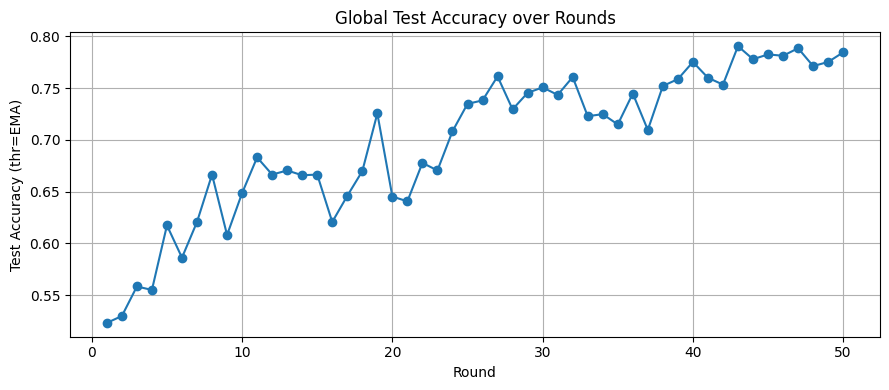

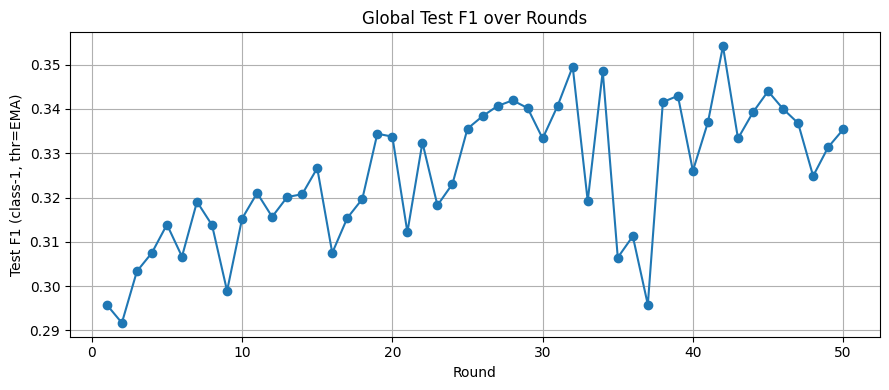

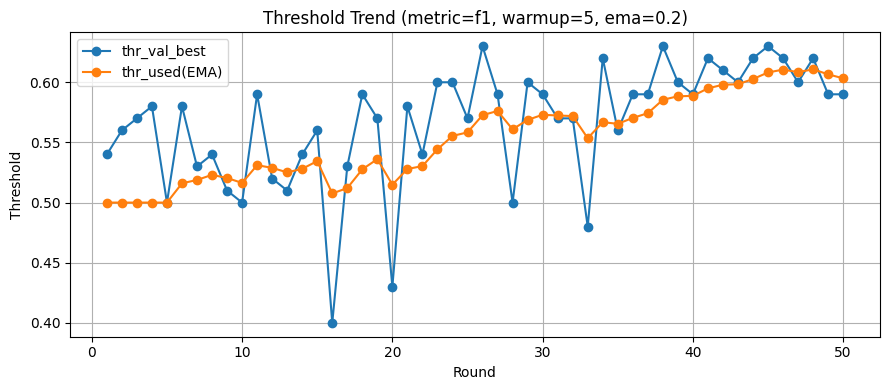

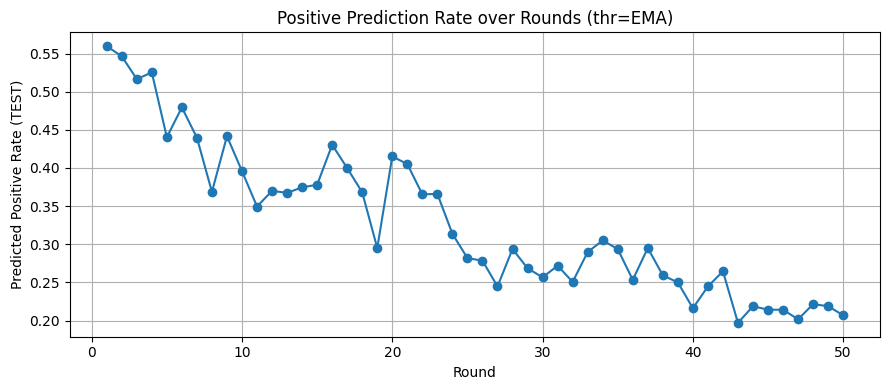


 Final Global Evaluation
Final thr_used(EMA)=0.60 | Acc=0.7845 | F1=0.3354 | pos_rate=0.207
CM: TN=1101, FP=230, FN=95, TP=82
              precision    recall  f1-score   support

           0     0.9206    0.8272    0.8714      1331
           1     0.2628    0.4633    0.3354       177

    accuracy                         0.7845      1508
   macro avg     0.5917    0.6452    0.6034      1508
weighted avg     0.8434    0.7845    0.8085      1508


 Per-Client Fine-tuning Report

--- Client A Fine-tuning ---
[Client A] thr=0.60 | Acc=0.7727 | F1=0.3478 | pos_rate=0.217
CM: TN=470, FP=103, FN=47, TP=40
              precision    recall  f1-score   support

           0     0.9091    0.8202    0.8624       573
           1     0.2797    0.4598    0.3478        87

    accuracy                         0.7727       660
   macro avg     0.5944    0.6400    0.6051       660
weighted avg     0.8261    0.7727    0.7946       660


--- Client B Fine-tuning ---
[Client B] thr=0.60 | Acc=0.8113

In [ ]:
# ============================================================
# Federated Learning (DeepMLP)
# + αᵢ Mitigation (n_i, c_i, t_i) softmax aggregation
# + Train-only SMOTE (per-client)
# + FocalLoss + FedProx + FedBN-style aggregation
# + Threshold tuning on VAL + EMA-smoothed threshold (NO test tuning)
# + Round logging: Global(Test) Acc/F1/CM + Local(Test) Acc
# + Final: Global report + Per-client fine-tuning report
# ============================================================

import os, math, copy, random, argparse
import pandas as pd
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    f1_score, confusion_matrix, precision_score, recall_score, classification_report
)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# -----------------------------
# 0) Reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEFECT_LABELS = [
    'Short_Shot_1', 'Bubble_1', 'Exfoliation_1', 'Blow_Hole_1', 'Deformation_1'
]

# αᵢ hyperparams
RHO   = 1.2
BETA  = 1.0
THETA = 1.0


# =========================================================
# 1) Data load + split + (SMOTE only on TRAIN)
# =========================================================
def load_excel_binary_raw(path):
    df = pd.read_excel(path).dropna(axis=1, how='all')

    for col in DEFECT_LABELS:
        if col not in df.columns:
            df[col] = 0

    y = df[DEFECT_LABELS].sum(axis=1).clip(upper=1).astype(int).values

    X = (
        df.drop(columns=DEFECT_LABELS, errors='ignore')
          .select_dtypes(include=[np.number])
          .replace([np.inf, -np.inf], np.nan)
          .dropna(axis=0, how='any')
    )
    y = y[:len(X)]
    return X, y


def oversample_train_only(X_train, y_train, sampling_strategy=1.0, k_neighbors=5):
    # NOTE: train-only SMOTE (never on val/test)
    sm = SMOTE(random_state=SEED, k_neighbors=k_neighbors, sampling_strategy=sampling_strategy)
    X_res, y_res = sm.fit_resample(X_train, y_train)
    return X_res, y_res


def build_clients(path_map, train_ratio=0.7, val_ratio=0.1, test_ratio=0.2,
                  smote_sampling_strategy=1.0, smote_k=5):
    assert abs((train_ratio + val_ratio + test_ratio) - 1.0) < 1e-9

    raw = {}
    for cid, path in path_map.items():
        X, y = load_excel_binary_raw(path)
        raw[cid] = {"X": X, "y": y}
        print(f"[Client {cid}] raw → shape: {X.shape}, class balance: {pd.Series(y).value_counts().to_dict()}")

    # common columns across clients
    cols = set.intersection(*[set(v["X"].columns) for v in raw.values()])
    cols = list(cols)

    clients, metas = {}, {}
    for cid, v in raw.items():
        feat_all = v["X"][cols].copy()
        y_all = v["y"].astype(int)

        n = len(feat_all)
        idx = np.arange(n)
        rng = np.random.RandomState(SEED)
        rng.shuffle(idx)

        n_train = int(train_ratio * n)
        n_val   = int(val_ratio * n)

        tr_idx = idx[:n_train]
        va_idx = idx[n_train:n_train+n_val]
        te_idx = idx[n_train+n_val:]

        X_train_raw = feat_all.iloc[tr_idx].copy()
        y_train_raw = y_all[tr_idx]

        X_val_raw   = feat_all.iloc[va_idx].copy()
        y_val_raw   = y_all[va_idx]

        X_test_raw  = feat_all.iloc[te_idx].copy()
        y_test_raw  = y_all[te_idx]

        # standardize with TRAIN stats only
        mu = X_train_raw.mean()
        sigma = X_train_raw.std().replace(0, 1)

        X_train_std = (X_train_raw - mu) / sigma
        X_val_std   = (X_val_raw   - mu) / sigma
        X_test_std  = (X_test_raw  - mu) / sigma

        # train-only SMOTE
        X_train_sm, y_train_sm = oversample_train_only(
            X_train_std, y_train_raw,
            sampling_strategy=smote_sampling_strategy,
            k_neighbors=smote_k
        )

        print(f"[Client {cid}] train after SMOTE → shape: {X_train_sm.shape}, class balance: {pd.Series(y_train_sm).value_counts().to_dict()}")
        print(f"[Client {cid}] val   (no SMOTE)   → shape: {X_val_std.shape}, class balance: {pd.Series(y_val_raw).value_counts().to_dict()}")
        print(f"[Client {cid}] test  (no SMOTE)   → shape: {X_test_std.shape}, class balance: {pd.Series(y_test_raw).value_counts().to_dict()}")

        Xtr = torch.tensor(np.asarray(X_train_sm).astype(np.float32))
        ytr = torch.tensor(y_train_sm, dtype=torch.long)

        Xva = torch.tensor(np.asarray(X_val_std).astype(np.float32))
        yva = torch.tensor(y_val_raw, dtype=torch.long)

        Xte = torch.tensor(np.asarray(X_test_std).astype(np.float32))
        yte = torch.tensor(y_test_raw, dtype=torch.long)

        clients[cid] = {
            "train": TensorDataset(Xtr, ytr),
            "val":   TensorDataset(Xva, yva),
            "test":  TensorDataset(Xte, yte),
        }

        metas[cid] = {
            "n_samples_raw": int(len(y_all)),
            "train_class_counts_raw": pd.Series(y_train_raw).value_counts().to_dict(),
            "val_class_counts_raw":   pd.Series(y_val_raw).value_counts().to_dict(),
            "test_class_counts_raw":  pd.Series(y_test_raw).value_counts().to_dict(),
        }

    return clients, metas, cols


# =========================================================
# 2) Model
# =========================================================
class DeepMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x):
        return self.net(x)


# =========================================================
# 3) Focal Loss
# =========================================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=2.0, gamma=1.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)
        loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return loss.mean()


# =========================================================
# 4) αᵢ components + aggregation
# =========================================================
def compute_ci(counts, eps_frac=0.05, min_samples=1):
    # counts: dict label->count
    K = len(counts)
    total = sum(counts.values())
    if K == 0 or total == 0:
        return 1e-8

    H = -sum((c / total) * math.log(c / total) for c in counts.values() if c > 0)

    logK = math.log(K + 1e-12)
    H_floor = eps_frac * logK
    H_tilde = max(H, H_floor)

    k_i = sum(1 for c in counts.values() if c >= min_samples)
    frac_k = k_i / K

    return max(1e-8, frac_k * (H_tilde / logK))


def aggregate_with_softmax_weights(state_dicts, alpha_components, rho, beta, theta, use_fedbn=True, alpha_temp=1.0):
    """
    αᵢ = softmax( (log(nᵢ^ρ)+log(cᵢ^β)+log(tᵢ^θ)) * alpha_temp )
    alpha_temp>1: sharper weights, <1: smoother weights
    """
    logits = {}
    for cid, comp in alpha_components.items():
        s = (
            math.log(comp["n_i"]**rho + 1e-12) +
            math.log(comp["c_i"]**beta + 1e-12) +
            math.log(comp["t_i"]**theta + 1e-12)
        )
        logits[cid] = s * float(alpha_temp)

    max_log = max(logits.values())
    exp_logits = {cid: math.exp(logits[cid] - max_log) for cid in logits}
    total_exp = sum(exp_logits.values())
    alphas = {cid: exp_logits[cid] / total_exp for cid in logits}

    base_sd = next(iter(state_dicts.values()))
    global_sd = {}

    for k in base_sd.keys():
        if use_fedbn and ("bn" in k or "running_mean" in k or "running_var" in k):
            global_sd[k] = base_sd[k].clone()
        else:
            global_sd[k] = sum(sd[k] * alphas[cid] for cid, sd in state_dicts.items()).clone()

    return global_sd, alphas


# =========================================================
# 5) Local Train (FedProx)
# =========================================================
def local_train(base_model, dataset, lr, epochs, device, global_params, mu):
    model = copy.deepcopy(base_model).to(device)
    model.train()

    crit = FocalLoss(alpha=2.0, gamma=1.5)
    opt  = optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(dataset, batch_size=64, shuffle=True)

    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()

            logits = model(x)
            loss = crit(logits, y)

            if mu > 0:
                prox = 0.0
                for p, g in zip(model.parameters(), global_params):
                    prox = prox + torch.norm(p - g) ** 2
                loss = loss + 0.5 * mu * prox

            loss.backward()
            opt.step()

    return model.state_dict()


# =========================================================
# 6) Predict + threshold search + evaluate
# =========================================================
def predict_probs(model, dataset, device):
    model.eval()
    loader = DataLoader(dataset, batch_size=256, shuffle=False)
    probs_all, y_all = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
            probs_all.append(probs)
            y_all.append(y.numpy())

    return np.concatenate(probs_all), np.concatenate(y_all)


def find_best_threshold_from_probs(probs, y_true, metric="f1", grid=None):
    if grid is None:
        grid = np.round(np.arange(0.05, 0.96, 0.01), 2)

    best_t, best_score = 0.5, -1e18
    best_aux = -1e18

    for t in grid:
        y_pred = (probs >= t).astype(int)

        if metric == "f1":
            score = f1_score(y_true, y_pred, zero_division=0)
            if score > best_score:
                best_score, best_t = score, t

        elif metric == "recall":
            rec = recall_score(y_true, y_pred, zero_division=0)
            prec = precision_score(y_true, y_pred, zero_division=0)
            if rec > best_score or (rec == best_score and prec > best_aux):
                best_score, best_aux, best_t = rec, prec, t

        elif metric == "youden":
            cm = confusion_matrix(y_true, y_pred)
            if cm.size != 4:
                continue
            tn, fp, fn, tp = cm.ravel()
            tpr = tp / (tp + fn + 1e-12)
            fpr = fp / (fp + tn + 1e-12)
            score = tpr - fpr
            if score > best_score:
                best_score, best_t = score, t
        else:
            raise ValueError("metric must be one of: f1, recall, youden")

    return float(best_t), float(best_score)


def evaluate_with_threshold(model, dataset, device, threshold):
    probs, y_true = predict_probs(model, dataset, device)
    y_pred = (probs >= threshold).astype(int)

    acc = float(np.mean(y_true == y_pred))
    f1  = float(f1_score(y_true, y_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    if cm.size == 4:
        tn, fp, fn, tp = cm.ravel()
    else:
        tn = fp = fn = tp = 0

    return acc, f1, (tn, fp, fn, tp), y_true, y_pred, float(np.mean(y_pred))  # pos_rate


# =========================================================
# 7) Fine-tuning
# =========================================================
def finetune_local(model, train_ds, device, lr=8e-4, epochs=5):
    ft_model = copy.deepcopy(model).to(device)
    ft_model.train()

    crit = FocalLoss(alpha=2.0, gamma=1.5)
    opt  = optim.Adam(ft_model.parameters(), lr=lr)
    loader = DataLoader(train_ds, batch_size=64, shuffle=True)

    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            logits = ft_model(x)
            loss = crit(logits, y)
            loss.backward()
            opt.step()

    return ft_model


# =========================================================
# 8) Main
# =========================================================
if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--rounds", type=int, default=50)

    parser.add_argument("--mu", type=float, default=0.003)
    parser.add_argument("--lr", type=float, default=8e-4)
    parser.add_argument("--local_epochs", type=int, default=5)

    parser.add_argument("--smote_ratio", type=float, default=1.0)     # 1.0 => 1:1
    parser.add_argument("--smote_k", type=int, default=5)

    parser.add_argument("--alpha_temp", type=float, default=1.0)      # 1.0 normal, <1 smoother, >1 sharper

    parser.add_argument("--th_metric", type=str, default="f1")        # f1 / recall / youden
    parser.add_argument("--thr_warmup", type=int, default=5)          # first N rounds use fixed threshold
    parser.add_argument("--thr_init", type=float, default=0.50)       # initial threshold
    parser.add_argument("--thr_ema", type=float, default=0.20)        # EMA rate λ (0.1~0.2 recommended)
    parser.add_argument("--thr_grid_min", type=float, default=0.05)
    parser.add_argument("--thr_grid_max", type=float, default=0.95)
    parser.add_argument("--thr_grid_step", type=float, default=0.01)

    parser.add_argument("--ft_epochs", type=int, default=5)
    args, _ = parser.parse_known_args()

    paths = {"A": "A.xlsx", "B": "B.xlsx", "C": "C.xlsx", "D": "D.xlsx"}
    clients, metas, cols = build_clients(
        paths,
        train_ratio=0.7, val_ratio=0.1, test_ratio=0.2,
        smote_sampling_strategy=args.smote_ratio,
        smote_k=args.smote_k
    )

    device = "cuda" if torch.cuda.is_available() else "cpu"
    input_dim = clients["A"]["train"].tensors[0].shape[1]
    global_model = DeepMLP(input_dim).to(device)

    # participation probabilities (keep probabilistic, no min participants)
    participation_probs = {"A": 0.9, "C": 0.7, "B": 0.4, "D": 0.4}

    combined_val  = torch.utils.data.ConcatDataset([v["val"]  for v in clients.values()])
    combined_test = torch.utils.data.ConcatDataset([v["test"] for v in clients.values()])

    # histories
    global_acc_history = []
    global_f1_history  = []
    thr_val_history    = []
    thr_used_history   = []
    pos_rate_history   = []
    alpha_history      = []
    round_conf_matrices = {}

    # EMA threshold state
    thr_used = float(args.thr_init)

    thr_grid = np.round(
        np.arange(args.thr_grid_min, args.thr_grid_max + 1e-12, args.thr_grid_step), 2
    )

    for rnd in range(1, args.rounds + 1):
        print(f"\n=== Round {rnd} ===")

        selected = [cid for cid in clients if random.random() < participation_probs[cid]]
        if len(selected) == 0:
            selected = [random.choice(list(clients.keys()))]
        print(" Participating:", selected)

        state_dicts = {}
        alpha_components = {}
        global_params = [p.detach().clone() for p in global_model.parameters()]

        # local train
        for cid in selected:
            ds_train = clients[cid]["train"]
            class_counts_raw = metas[cid]["train_class_counts_raw"]

            sd = local_train(
                base_model=global_model,
                dataset=ds_train,
                lr=args.lr,
                epochs=args.local_epochs,
                device=device,
                global_params=global_params,
                mu=args.mu
            )
            state_dicts[cid] = sd

            n_i = math.sqrt(metas[cid]["n_samples_raw"])
            c_i = compute_ci(class_counts_raw)
            t_i = participation_probs[cid]
            alpha_components[cid] = {"n_i": n_i, "c_i": c_i, "t_i": t_i}

        new_global_sd, alphas = aggregate_with_softmax_weights(
            state_dicts,
            alpha_components,
            rho=RHO, beta=BETA, theta=THETA,
            use_fedbn=True,
            alpha_temp=args.alpha_temp
        )
        global_model.load_state_dict(new_global_sd)
        alpha_history.append((rnd, alphas))

        # ----- threshold tuning on VAL only -----
        val_probs, val_true = predict_probs(global_model, combined_val, device)
        thr_val_best, thr_val_score = find_best_threshold_from_probs(
            val_probs, val_true, metric=args.th_metric, grid=thr_grid
        )
        thr_val_history.append(thr_val_best)

        # ----- EMA threshold update (after warmup) -----
        if rnd <= args.thr_warmup:
            thr_used = float(args.thr_init)
        else:
            lam = float(args.thr_ema)
            thr_used = (1.0 - lam) * thr_used + lam * thr_val_best

        thr_used_history.append(float(thr_used))

        # evaluate on TEST with thr_used (EMA)
        test_acc, test_f1, (tn, fp, fn, tp), _, _, pos_rate = evaluate_with_threshold(
            global_model, combined_test, device, threshold=thr_used
        )

        global_acc_history.append(test_acc)
        global_f1_history.append(test_f1)
        pos_rate_history.append(pos_rate)
        round_conf_matrices[rnd] = np.array([[tn, fp], [fn, tp]])

        print(f"[Round {rnd}] alpha_temp={args.alpha_temp:.2f}, mu={args.mu:.4f}")
        print(f"[Round {rnd}] tuned thr@VAL({args.th_metric})={thr_val_best:.2f} (score={thr_val_score:.4f}) | thr_used(EMA)={thr_used:.2f} | pos_rate_test={pos_rate:.3f}")
        print(f"[Round {rnd}] TEST  Acc={test_acc:.4f}, F1={test_f1:.4f}, TN={tn}, FP={fp}, FN={fn}, TP={tp}")

    # =========================
    # Curves
    # =========================
    rounds_axis = list(range(1, args.rounds + 1))

    plt.figure(figsize=(9,4))
    plt.plot(rounds_axis, global_acc_history, marker='o')
    plt.xlabel("Round")
    plt.ylabel("Test Accuracy (thr=EMA)")
    plt.title("Global Test Accuracy over Rounds")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9,4))
    plt.plot(rounds_axis, global_f1_history, marker='o')
    plt.xlabel("Round")
    plt.ylabel("Test F1 (class-1, thr=EMA)")
    plt.title("Global Test F1 over Rounds")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9,4))
    plt.plot(rounds_axis, thr_val_history, marker='o', label="thr_val_best")
    plt.plot(rounds_axis, thr_used_history, marker='o', label="thr_used(EMA)")
    plt.xlabel("Round")
    plt.ylabel("Threshold")
    plt.title(f"Threshold Trend (metric={args.th_metric}, warmup={args.thr_warmup}, ema={args.thr_ema})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9,4))
    plt.plot(rounds_axis, pos_rate_history, marker='o')
    plt.xlabel("Round")
    plt.ylabel("Predicted Positive Rate (TEST)")
    plt.title("Positive Prediction Rate over Rounds (thr=EMA)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # =========================
    # Final Global Report (thr=EMA last)
    # =========================
    final_thr = float(thr_used_history[-1]) if len(thr_used_history) else float(args.thr_init)
    acc, f1, (tn, fp, fn, tp), y_true, y_pred, pos_rate = evaluate_with_threshold(
        global_model, combined_test, device, threshold=final_thr
    )
    print("\n==============================")
    print(" Final Global Evaluation")
    print("==============================")
    print(f"Final thr_used(EMA)={final_thr:.2f} | Acc={acc:.4f} | F1={f1:.4f} | pos_rate={pos_rate:.3f}")
    print(f"CM: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    print(classification_report(y_true, y_pred, digits=4, zero_division=0))

    # =========================
    # Per-client Fine-tuning (thr fixed to final_thr)
    # =========================
    print("\n==============================")
    print(" Per-Client Fine-tuning Report")
    print("==============================")

    for cid in clients.keys():
        print(f"\n--- Client {cid} Fine-tuning ---")
        ft_model = finetune_local(
            model=global_model,
            train_ds=clients[cid]["train"],
            device=device,
            lr=args.lr,
            epochs=args.ft_epochs
        )

        acc_c, f1_c, (tn, fp, fn, tp), ytc, ypc, pos_rate_c = evaluate_with_threshold(
            ft_model, clients[cid]["test"], device, threshold=final_thr
        )
        print(f"[Client {cid}] thr={final_thr:.2f} | Acc={acc_c:.4f} | F1={f1_c:.4f} | pos_rate={pos_rate_c:.3f}")
        print(f"CM: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
        print(classification_report(ytc, ypc, digits=4, zero_division=0))


# 실험

[Client A] raw → shape: (3300, 16), class balance: {0: 2831, 1: 469}
[Client B] raw → shape: (530, 16), class balance: {0: 474, 1: 56}
[Client C] raw → shape: (3245, 16), class balance: {0: 2915, 1: 330}
[Client D] raw → shape: (460, 16), class balance: {0: 406, 1: 54}
[Client A] train after SMOTE(safe) → shape: (3958, 16), class balance: {0: 1979, 1: 1979}
[Client A] val   (no SMOTE)        → shape: (330, 16), class balance: {0: 279, 1: 51}
[Client A] test  (no SMOTE)        → shape: (660, 16), class balance: {0: 573, 1: 87}
[Client B] train after SMOTE(safe) → shape: (664, 16), class balance: {0: 332, 1: 332}
[Client B] val   (no SMOTE)        → shape: (53, 16), class balance: {0: 48, 1: 5}
[Client B] test  (no SMOTE)        → shape: (106, 16), class balance: {0: 94, 1: 12}
[Client C] train after SMOTE(safe) → shape: (4100, 16), class balance: {1: 2050, 0: 2050}
[Client C] val   (no SMOTE)        → shape: (324, 16), class balance: {0: 285, 1: 39}
[Client C] test  (no SMOTE)        → 

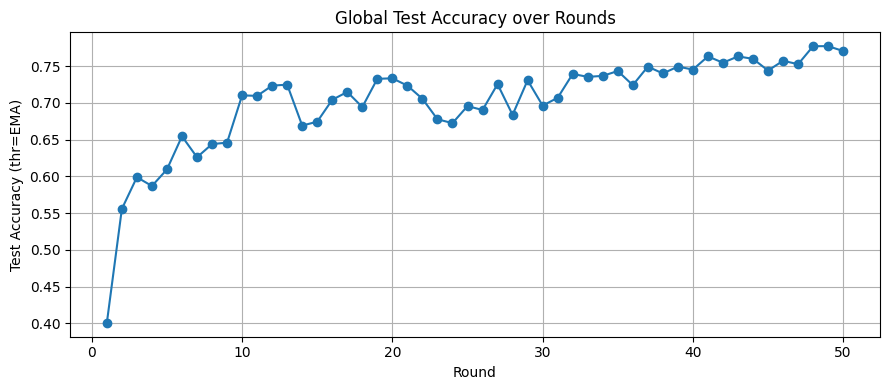

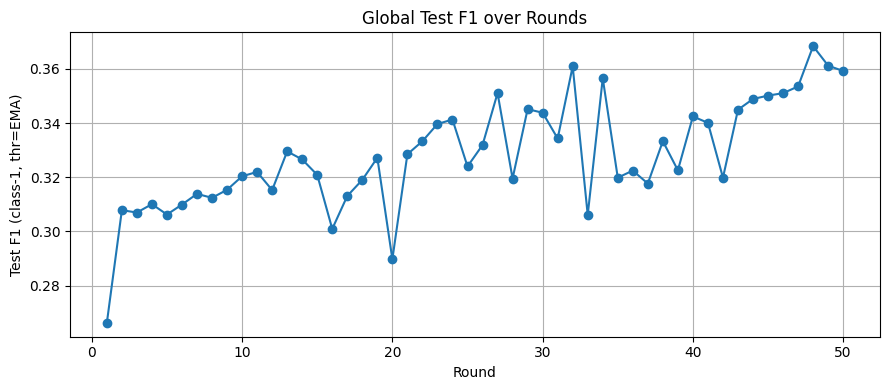

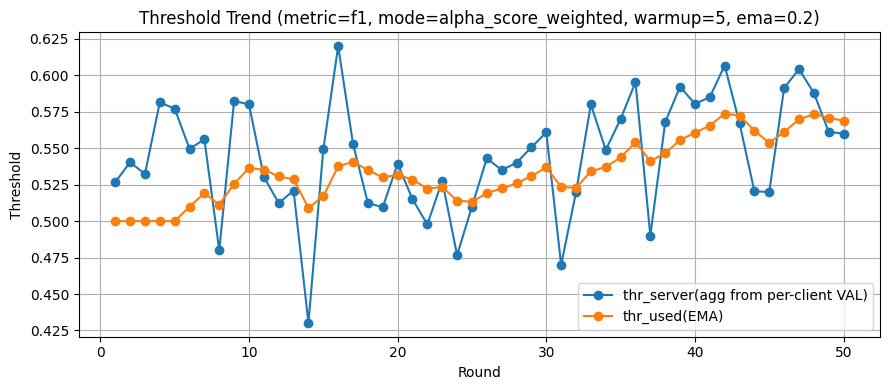

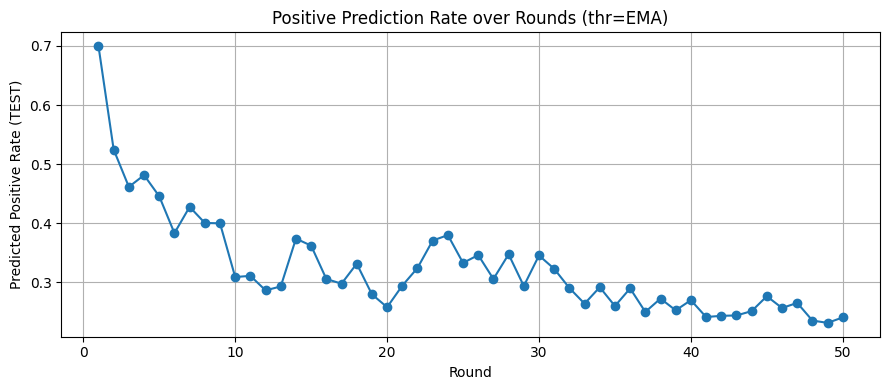


 Final Global Evaluation
Final thr_used(EMA)=0.57 | Acc=0.7706 | F1=0.3593 | pos_rate=0.241
CM: TN=1065, FP=266, FN=80, TP=97
              precision    recall  f1-score   support

           0     0.9301    0.8002    0.8603      1331
           1     0.2672    0.5480    0.3593       177

    accuracy                         0.7706      1508
   macro avg     0.5987    0.6741    0.6098      1508
weighted avg     0.8523    0.7706    0.8015      1508


 Per-Client Fine-tuning Report

--- Client A Fine-tuning ---
[Client A] thr=0.57 | Acc=0.7576 | F1=0.3846 | pos_rate=0.262
CM: TN=450, FP=123, FN=37, TP=50
              precision    recall  f1-score   support

           0     0.9240    0.7853    0.8491       573
           1     0.2890    0.5747    0.3846        87

    accuracy                         0.7576       660
   macro avg     0.6065    0.6800    0.6168       660
weighted avg     0.8403    0.7576    0.7878       660


--- Client B Fine-tuning ---
[Client B] thr=0.57 | Acc=0.7642

In [ ]:
# ============================================================
# Federated Learning (DeepMLP)
# + αᵢ Mitigation (n_i, c_i, t_i) softmax aggregation
# + Train-only SMOTE (per-client) with safe k + bypass
# + FocalLoss + FedProx + FedBN-style aggregation
# + Threshold tuning: per-client VAL -> server aggregation (NO test tuning)
# + Threshold EMA smoothing (global), warmup supported
# + t_i: 실제 참여 기반(누적/최근W/EMA 중 선택)
# + Round logging: Global(Test) Acc/F1/CM + Local(Test) Acc
# + Final: Global report + Per-client fine-tuning report
# ============================================================

import os, math, copy, random, argparse
import pandas as pd
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    f1_score, confusion_matrix, precision_score, recall_score, classification_report
)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt


# -----------------------------
# 0) Reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEFECT_LABELS = [
    'Short_Shot_1', 'Bubble_1', 'Exfoliation_1', 'Blow_Hole_1', 'Deformation_1'
]

# αᵢ hyperparams (aggregation)
RHO   = 1.2
BETA  = 1.0
THETA = 1.0


# =========================================================
# 1) Data load + split + (SMOTE only on TRAIN) with safeguards
# =========================================================
def load_excel_binary_raw(path):
    df = pd.read_excel(path).dropna(axis=1, how='all')

    for col in DEFECT_LABELS:
        if col not in df.columns:
            df[col] = 0

    y = df[DEFECT_LABELS].sum(axis=1).clip(upper=1).astype(int).values

    X = (
        df.drop(columns=DEFECT_LABELS, errors='ignore')
          .select_dtypes(include=[np.number])
          .replace([np.inf, -np.inf], np.nan)
          .dropna(axis=0, how='any')
    )
    y = y[:len(X)]
    return X, y


def safe_smote_train_only(X_train, y_train, sampling_strategy=1.0, k_neighbors=5, min_minority=2):
    """
    Train-only SMOTE with:
      - automatic k adjustment (<= minority_count-1)
      - bypass if minority too small
      - bypass if only one class exists
    """
    y_train = np.asarray(y_train).astype(int)

    # must have both classes
    uniq, cnts = np.unique(y_train, return_counts=True)
    if len(uniq) < 2:
        return X_train, y_train  # bypass: single class

    # assume binary {0,1}; minority count:
    c0 = int(np.sum(y_train == 0))
    c1 = int(np.sum(y_train == 1))
    minority_count = min(c0, c1)

    if minority_count < int(min_minority):
        return X_train, y_train  # bypass: too few minority

    # k must be <= minority_count - 1
    k_eff = int(min(k_neighbors, max(1, minority_count - 1)))

    try:
        sm = SMOTE(random_state=SEED, k_neighbors=k_eff, sampling_strategy=sampling_strategy)
        X_res, y_res = sm.fit_resample(X_train, y_train)
        return X_res, y_res
    except Exception:
        # any SMOTE failure -> bypass (safe)
        return X_train, y_train


def build_clients(path_map, train_ratio=0.7, val_ratio=0.1, test_ratio=0.2,
                  smote_sampling_strategy=1.0, smote_k=5, smote_min_minority=2):
    assert abs((train_ratio + val_ratio + test_ratio) - 1.0) < 1e-9

    raw = {}
    for cid, path in path_map.items():
        X, y = load_excel_binary_raw(path)
        raw[cid] = {"X": X, "y": y}
        print(f"[Client {cid}] raw → shape: {X.shape}, class balance: {pd.Series(y).value_counts().to_dict()}")

    # common columns across clients
    cols = set.intersection(*[set(v["X"].columns) for v in raw.values()])
    cols = list(cols)

    clients, metas = {}, {}
    for cid, v in raw.items():
        feat_all = v["X"][cols].copy()
        y_all = v["y"].astype(int)

        n = len(feat_all)
        idx = np.arange(n)
        rng = np.random.RandomState(SEED)
        rng.shuffle(idx)

        n_train = int(train_ratio * n)
        n_val   = int(val_ratio * n)

        tr_idx = idx[:n_train]
        va_idx = idx[n_train:n_train+n_val]
        te_idx = idx[n_train+n_val:]

        X_train_raw = feat_all.iloc[tr_idx].copy()
        y_train_raw = y_all[tr_idx]

        X_val_raw   = feat_all.iloc[va_idx].copy()
        y_val_raw   = y_all[va_idx]

        X_test_raw  = feat_all.iloc[te_idx].copy()
        y_test_raw  = y_all[te_idx]

        # standardize with TRAIN stats only
        mu = X_train_raw.mean()
        sigma = X_train_raw.std().replace(0, 1)

        X_train_std = (X_train_raw - mu) / sigma
        X_val_std   = (X_val_raw   - mu) / sigma
        X_test_std  = (X_test_raw  - mu) / sigma

        # train-only SMOTE (safe)
        X_train_sm, y_train_sm = safe_smote_train_only(
            X_train_std, y_train_raw,
            sampling_strategy=smote_sampling_strategy,
            k_neighbors=smote_k,
            min_minority=smote_min_minority
        )

        print(f"[Client {cid}] train after SMOTE(safe) → shape: {np.asarray(X_train_sm).shape}, class balance: {pd.Series(y_train_sm).value_counts().to_dict()}")
        print(f"[Client {cid}] val   (no SMOTE)        → shape: {X_val_std.shape}, class balance: {pd.Series(y_val_raw).value_counts().to_dict()}")
        print(f"[Client {cid}] test  (no SMOTE)        → shape: {X_test_std.shape}, class balance: {pd.Series(y_test_raw).value_counts().to_dict()}")

        Xtr = torch.tensor(np.asarray(X_train_sm).astype(np.float32))
        ytr = torch.tensor(np.asarray(y_train_sm).astype(int), dtype=torch.long)

        Xva = torch.tensor(np.asarray(X_val_std).astype(np.float32))
        yva = torch.tensor(np.asarray(y_val_raw).astype(int), dtype=torch.long)

        Xte = torch.tensor(np.asarray(X_test_std).astype(np.float32))
        yte = torch.tensor(np.asarray(y_test_raw).astype(int), dtype=torch.long)

        clients[cid] = {
            "train": TensorDataset(Xtr, ytr),
            "val":   TensorDataset(Xva, yva),
            "test":  TensorDataset(Xte, yte),
        }

        metas[cid] = {
            "n_samples_raw": int(len(y_all)),
            "train_class_counts_raw": pd.Series(y_train_raw).value_counts().to_dict(),
            "val_class_counts_raw":   pd.Series(y_val_raw).value_counts().to_dict(),
            "test_class_counts_raw":  pd.Series(y_test_raw).value_counts().to_dict(),
        }

    return clients, metas, cols


# =========================================================
# 2) Model
# =========================================================
class DeepMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x):
        return self.net(x)


# =========================================================
# 3) Focal Loss
# =========================================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=2.0, gamma=1.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)
        loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return loss.mean()


# =========================================================
# 4) αᵢ components + aggregation
# =========================================================
def compute_ci(counts, eps_frac=0.05, min_samples=1):
    # counts: dict label->count
    K = len(counts)
    total = sum(counts.values())
    if K == 0 or total == 0:
        return 1e-8

    H = -sum((c / total) * math.log(c / total) for c in counts.values() if c > 0)
    logK = math.log(K + 1e-12)

    H_floor = eps_frac * logK
    H_tilde = max(H, H_floor)

    k_i = sum(1 for c in counts.values() if c >= min_samples)
    frac_k = k_i / K

    return max(1e-8, frac_k * (H_tilde / logK))


def aggregate_with_softmax_weights(state_dicts, alpha_components, rho, beta, theta, use_fedbn=True, alpha_temp=1.0):
    """
    αᵢ = softmax( (log(nᵢ^ρ)+log(cᵢ^β)+log(tᵢ^θ)) * alpha_temp )
    alpha_temp>1: sharper weights, <1: smoother weights
    """
    logits = {}
    for cid, comp in alpha_components.items():
        s = (
            math.log(comp["n_i"]**rho + 1e-12) +
            math.log(comp["c_i"]**beta + 1e-12) +
            math.log(comp["t_i"]**theta + 1e-12)
        )
        logits[cid] = s * float(alpha_temp)

    max_log = max(logits.values())
    exp_logits = {cid: math.exp(logits[cid] - max_log) for cid in logits}
    total_exp = sum(exp_logits.values())
    alphas = {cid: exp_logits[cid] / total_exp for cid in logits}

    base_sd = next(iter(state_dicts.values()))
    global_sd = {}

    for k in base_sd.keys():
        if use_fedbn and ("bn" in k or "running_mean" in k or "running_var" in k):
            # FedBN-style: keep BN from a reference client (here: first in dict)
            global_sd[k] = base_sd[k].clone()
        else:
            global_sd[k] = sum(sd[k] * alphas[cid] for cid, sd in state_dicts.items()).clone()

    return global_sd, alphas


# =========================================================
# 5) Local Train (FedProx)
# =========================================================
def local_train(base_model, dataset, lr, epochs, device, global_params, mu):
    model = copy.deepcopy(base_model).to(device)
    model.train()

    crit = FocalLoss(alpha=2.0, gamma=1.5)
    opt  = optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(dataset, batch_size=64, shuffle=True)

    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()

            logits = model(x)
            loss = crit(logits, y)

            if mu > 0:
                prox = 0.0
                for p, g in zip(model.parameters(), global_params):
                    prox = prox + torch.norm(p - g) ** 2
                loss = loss + 0.5 * mu * prox

            loss.backward()
            opt.step()

    return model.state_dict()


# =========================================================
# 6) Predict + threshold search + evaluate
# =========================================================
def predict_probs(model, dataset, device):
    model.eval()
    loader = DataLoader(dataset, batch_size=256, shuffle=False)
    probs_all, y_all = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
            probs_all.append(probs)
            y_all.append(y.numpy())

    return np.concatenate(probs_all), np.concatenate(y_all)


def find_best_threshold_from_probs(probs, y_true, metric="f1", grid=None):
    if grid is None:
        grid = np.round(np.arange(0.05, 0.96, 0.01), 2)

    best_t, best_score = 0.5, -1e18
    best_aux = -1e18

    for t in grid:
        y_pred = (probs >= t).astype(int)

        if metric == "f1":
            score = f1_score(y_true, y_pred, zero_division=0)
            if score > best_score:
                best_score, best_t = score, t

        elif metric == "recall":
            rec = recall_score(y_true, y_pred, zero_division=0)
            prec = precision_score(y_true, y_pred, zero_division=0)
            if rec > best_score or (rec == best_score and prec > best_aux):
                best_score, best_aux, best_t = rec, prec, t

        elif metric == "youden":
            cm = confusion_matrix(y_true, y_pred)
            if cm.size != 4:
                continue
            tn, fp, fn, tp = cm.ravel()
            tpr = tp / (tp + fn + 1e-12)
            fpr = fp / (fp + tn + 1e-12)
            score = tpr - fpr
            if score > best_score:
                best_score, best_t = score, t
        else:
            raise ValueError("metric must be one of: f1, recall, youden")

    return float(best_t), float(best_score)


def evaluate_with_threshold(model, dataset, device, threshold):
    probs, y_true = predict_probs(model, dataset, device)
    y_pred = (probs >= threshold).astype(int)

    acc = float(np.mean(y_true == y_pred))
    f1  = float(f1_score(y_true, y_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    if cm.size == 4:
        tn, fp, fn, tp = cm.ravel()
    else:
        tn = fp = fn = tp = 0

    return acc, f1, (tn, fp, fn, tp), y_true, y_pred, float(np.mean(y_pred))  # pos_rate


# =========================================================
# 6-1) Threshold: per-client VAL -> server aggregation
# =========================================================
def server_aggregate_threshold(per_client_thr, per_client_score, thr_mode="alpha_weighted",
                              alpha_weights=None, score_power=1.0, clip=(0.05, 0.95)):
    """
    per_client_thr:   dict[cid] -> thr*
    per_client_score: dict[cid] -> metric score at thr*
    thr_mode:
      - "median": simple robust
      - "mean": simple average
      - "score_weighted": weight by (score^score_power)
      - "alpha_weighted": weight by alpha (needs alpha_weights)
      - "alpha_score_weighted": weight by alpha*(score^score_power)
    """
    cids = list(per_client_thr.keys())
    thrs = np.array([per_client_thr[c] for c in cids], dtype=float)

    if len(thrs) == 0:
        return 0.5

    if thr_mode == "median":
        thr = float(np.median(thrs))

    elif thr_mode == "mean":
        thr = float(np.mean(thrs))

    elif thr_mode == "score_weighted":
        w = np.array([max(1e-12, per_client_score.get(c, 0.0)) for c in cids], dtype=float) ** float(score_power)
        w = w / (w.sum() + 1e-12)
        thr = float((w * thrs).sum())

    elif thr_mode == "alpha_weighted":
        if alpha_weights is None:
            raise ValueError("alpha_weights required for alpha_weighted")
        w = np.array([max(1e-12, alpha_weights.get(c, 0.0)) for c in cids], dtype=float)
        w = w / (w.sum() + 1e-12)
        thr = float((w * thrs).sum())

    elif thr_mode == "alpha_score_weighted":
        if alpha_weights is None:
            raise ValueError("alpha_weights required for alpha_score_weighted")
        w_alpha = np.array([max(1e-12, alpha_weights.get(c, 0.0)) for c in cids], dtype=float)
        w_score = np.array([max(1e-12, per_client_score.get(c, 0.0)) for c in cids], dtype=float) ** float(score_power)
        w = w_alpha * w_score
        w = w / (w.sum() + 1e-12)
        thr = float((w * thrs).sum())

    else:
        raise ValueError("thr_mode must be one of: median, mean, score_weighted, alpha_weighted, alpha_score_weighted")

    lo, hi = clip
    thr = float(np.clip(thr, lo, hi))
    return thr


# =========================================================
# 6-2) t_i: 실제 참여 기반(누적/최근W/EMA)
# =========================================================
def compute_t_i(cid, rnd, participated_counts, selected_this_round,
                t_mode="ema", t_window=10, t_ema=0.2, t_min=0.05, t_max=0.95,
                t_ema_state=None):
    """
    t_mode:
      - "cum": 누적 참여율 = count/rnd
      - "window": 최근 W라운드 참여율
      - "ema": 참여(1)/미참여(0)로 EMA 업데이트
    """
    if t_mode == "cum":
        t = participated_counts[cid] / max(1, rnd)

    elif t_mode == "window":
        # selected history should be stored outside as list of dicts or list of sets
        # Here we assume participated_counts already includes cum, so we need an external history.
        raise RuntimeError("t_mode='window' requires history list; use compute_t_i_window() helper instead.")

    elif t_mode == "ema":
        if t_ema_state is None:
            raise ValueError("t_ema_state dict required for t_mode='ema'")
        x = 1.0 if selected_this_round else 0.0
        lam = float(t_ema)
        t_ema_state[cid] = (1.0 - lam) * float(t_ema_state[cid]) + lam * x
        t = float(t_ema_state[cid])

    else:
        raise ValueError("t_mode must be one of: cum, window, ema")

    return float(np.clip(t, t_min, t_max))


def compute_t_i_window(cid, history_selected_sets, t_window=10, t_min=0.05, t_max=0.95):
    last = history_selected_sets[-t_window:] if len(history_selected_sets) >= 1 else []
    if len(last) == 0:
        t = 0.0
    else:
        hits = sum(1 for s in last if cid in s)
        t = hits / len(last)
    return float(np.clip(t, t_min, t_max))


# =========================================================
# 7) Fine-tuning
# =========================================================
def finetune_local(model, train_ds, device, lr=8e-4, epochs=5):
    ft_model = copy.deepcopy(model).to(device)
    ft_model.train()

    crit = FocalLoss(alpha=2.0, gamma=1.5)
    opt  = optim.Adam(ft_model.parameters(), lr=lr)
    loader = DataLoader(train_ds, batch_size=64, shuffle=True)

    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            logits = ft_model(x)
            loss = crit(logits, y)
            loss.backward()
            opt.step()

    return ft_model


# =========================================================
# 8) Main
# =========================================================
if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--rounds", type=int, default=50)

    parser.add_argument("--mu", type=float, default=0.003)
    parser.add_argument("--lr", type=float, default=8e-4)
    parser.add_argument("--local_epochs", type=int, default=5)

    # SMOTE
    parser.add_argument("--smote_ratio", type=float, default=1.0)     # 1.0 => 1:1
    parser.add_argument("--smote_k", type=int, default=5)
    parser.add_argument("--smote_min_minority", type=int, default=2)  # minority < this => bypass

    # alpha softmax temperature
    parser.add_argument("--alpha_temp", type=float, default=1.0)

    # Threshold tuning (VAL only)
    parser.add_argument("--th_metric", type=str, default="f1")        # f1 / recall / youden
    parser.add_argument("--thr_mode", type=str, default="alpha_score_weighted")
    # thr_mode: median / mean / score_weighted / alpha_weighted / alpha_score_weighted

    parser.add_argument("--thr_warmup", type=int, default=5)
    parser.add_argument("--thr_init", type=float, default=0.50)
    parser.add_argument("--thr_ema", type=float, default=0.20)
    parser.add_argument("--thr_grid_min", type=float, default=0.05)
    parser.add_argument("--thr_grid_max", type=float, default=0.95)
    parser.add_argument("--thr_grid_step", type=float, default=0.01)
    parser.add_argument("--thr_score_power", type=float, default=1.0)  # for score_weighted modes

    # t_i (actual participation-based)
    parser.add_argument("--t_mode", type=str, default="ema")          # cum / window / ema
    parser.add_argument("--t_window", type=int, default=10)           # for window
    parser.add_argument("--t_ema", type=float, default=0.20)          # for ema
    parser.add_argument("--t_min", type=float, default=0.05)
    parser.add_argument("--t_max", type=float, default=0.95)

    # Fine-tuning
    parser.add_argument("--ft_epochs", type=int, default=5)

    args, _ = parser.parse_known_args()

    # paths
    paths = {"A": "A.xlsx", "B": "B.xlsx", "C": "C.xlsx", "D": "D.xlsx"}

    clients, metas, cols = build_clients(
        paths,
        train_ratio=0.7, val_ratio=0.1, test_ratio=0.2,
        smote_sampling_strategy=args.smote_ratio,
        smote_k=args.smote_k,
        smote_min_minority=args.smote_min_minority
    )

    device = "cuda" if torch.cuda.is_available() else "cpu"
    input_dim = clients["A"]["train"].tensors[0].shape[1]
    global_model = DeepMLP(input_dim).to(device)

    # base participation probabilities (sampling policy)
    participation_probs = {"A": 0.9, "C": 0.7, "B": 0.4, "D": 0.4}

    # threshold states
    thr_used = float(args.thr_init)

    thr_grid = np.round(
        np.arange(args.thr_grid_min, args.thr_grid_max + 1e-12, args.thr_grid_step), 2
    )

    # histories
    rounds_axis = list(range(1, args.rounds + 1))
    global_acc_history = []
    global_f1_history  = []
    thr_server_history = []   # server-aggregated thr from per-client val
    thr_used_history   = []   # EMA-smoothed thr actually used on TEST
    pos_rate_history   = []
    alpha_history      = []
    round_conf_matrices = {}
    selected_history_sets = []  # for t_mode="window"

    # participation tracking (actual)
    participated_counts = {cid: 0 for cid in clients.keys()}

    # t_ema state (init to base participation probs: 안정적 초기화)
    t_ema_state = {cid: float(participation_probs[cid]) for cid in clients.keys()}

    for rnd in range(1, args.rounds + 1):
        print(f"\n=== Round {rnd} ===")

        # probabilistic selection (policy)
        selected = [cid for cid in clients if random.random() < participation_probs[cid]]
        if len(selected) == 0:
            selected = [random.choice(list(clients.keys()))]
        selected_set = set(selected)
        selected_history_sets.append(selected_set)

        # update actual participation counts
        for cid in selected:
            participated_counts[cid] += 1

        print(" Participating:", selected)

        state_dicts = {}
        alpha_components = {}
        global_params = [p.detach().clone() for p in global_model.parameters()]

        # compute t_i for this round (actual-based)
        # (for selected clients only—because alpha only needs participating clients)
        for cid in selected:
            if args.t_mode == "cum":
                t_i = compute_t_i(
                    cid=cid, rnd=rnd,
                    participated_counts=participated_counts,
                    selected_this_round=True,
                    t_mode="cum",
                    t_min=args.t_min, t_max=args.t_max
                )
            elif args.t_mode == "ema":
                t_i = compute_t_i(
                    cid=cid, rnd=rnd,
                    participated_counts=participated_counts,
                    selected_this_round=True,
                    t_mode="ema",
                    t_ema=args.t_ema,
                    t_min=args.t_min, t_max=args.t_max,
                    t_ema_state=t_ema_state
                )
            elif args.t_mode == "window":
                # window uses history
                t_i = compute_t_i_window(
                    cid=cid,
                    history_selected_sets=selected_history_sets,
                    t_window=args.t_window,
                    t_min=args.t_min, t_max=args.t_max
                )
            else:
                raise ValueError("args.t_mode must be one of: cum, window, ema")

            # local train
            ds_train = clients[cid]["train"]
            class_counts_raw = metas[cid]["train_class_counts_raw"]

            sd = local_train(
                base_model=global_model,
                dataset=ds_train,
                lr=args.lr,
                epochs=args.local_epochs,
                device=device,
                global_params=global_params,
                mu=args.mu
            )
            state_dicts[cid] = sd

            # alpha components
            n_i = math.sqrt(metas[cid]["n_samples_raw"])
            c_i = compute_ci(class_counts_raw)
            alpha_components[cid] = {"n_i": n_i, "c_i": c_i, "t_i": float(t_i)}

        # (중요) EMA 방식일 때: 미참여 클라이언트도 0으로 업데이트해줘야 "실제 참여 기반"이 됨
        if args.t_mode == "ema":
            for cid in clients.keys():
                if cid not in selected_set:
                    compute_t_i(
                        cid=cid, rnd=rnd,
                        participated_counts=participated_counts,
                        selected_this_round=False,
                        t_mode="ema",
                        t_ema=args.t_ema,
                        t_min=args.t_min, t_max=args.t_max,
                        t_ema_state=t_ema_state
                    )

        # aggregation
        new_global_sd, alphas = aggregate_with_softmax_weights(
            state_dicts,
            alpha_components,
            rho=RHO, beta=BETA, theta=THETA,
            use_fedbn=True,
            alpha_temp=args.alpha_temp
        )
        global_model.load_state_dict(new_global_sd)
        alpha_history.append((rnd, alphas))

        # ----- threshold tuning (VAL) per-client -> server aggregation -----
        per_client_thr = {}
        per_client_score = {}

        for cid in selected:
            val_probs, val_true = predict_probs(global_model, clients[cid]["val"], device)
            thr_best, thr_score = find_best_threshold_from_probs(
                val_probs, val_true, metric=args.th_metric, grid=thr_grid
            )
            per_client_thr[cid] = float(thr_best)
            per_client_score[cid] = float(thr_score)

        thr_server = server_aggregate_threshold(
            per_client_thr=per_client_thr,
            per_client_score=per_client_score,
            thr_mode=args.thr_mode,
            alpha_weights=alphas,  # 참여한 클라이언트에 대해서만 존재
            score_power=args.thr_score_power,
            clip=(args.thr_grid_min, args.thr_grid_max)
        )
        thr_server_history.append(float(thr_server))

        # ----- EMA threshold update (after warmup) -----
        if rnd <= args.thr_warmup:
            thr_used = float(args.thr_init)
        else:
            lam = float(args.thr_ema)
            thr_used = (1.0 - lam) * thr_used + lam * float(thr_server)

        thr_used_history.append(float(thr_used))

        # evaluate on TEST with thr_used (EMA)
        combined_test = torch.utils.data.ConcatDataset([v["test"] for v in clients.values()])
        test_acc, test_f1, (tn, fp, fn, tp), _, _, pos_rate = evaluate_with_threshold(
            global_model, combined_test, device, threshold=thr_used
        )

        global_acc_history.append(test_acc)
        global_f1_history.append(test_f1)
        pos_rate_history.append(pos_rate)
        round_conf_matrices[rnd] = np.array([[tn, fp], [fn, tp]])

        # logs
        print(f"[Round {rnd}] alpha_temp={args.alpha_temp:.2f}, mu={args.mu:.4f}, t_mode={args.t_mode}")
        print(f"[Round {rnd}] per-client thr@VAL({args.th_metric})={ {k: round(v,2) for k,v in per_client_thr.items()} }")
        print(f"[Round {rnd}] server thr({args.thr_mode})={thr_server:.2f} | thr_used(EMA)={thr_used:.2f} | pos_rate_test={pos_rate:.3f}")
        print(f"[Round {rnd}] TEST  Acc={test_acc:.4f}, F1={test_f1:.4f}, TN={tn}, FP={fp}, FN={fn}, TP={tp}")
        print(f"[Round {rnd}] alphas={ {k: round(v,3) for k,v in alphas.items()} }")
        if args.t_mode == "cum":
            t_dbg = {cid: round(participated_counts[cid]/max(1,rnd), 3) for cid in clients.keys()}
            print(f"[Round {rnd}] t_i(cum all)={t_dbg}")
        elif args.t_mode == "ema":
            t_dbg = {cid: round(t_ema_state[cid], 3) for cid in clients.keys()}
            print(f"[Round {rnd}] t_i(ema all)={t_dbg}")
        elif args.t_mode == "window":
            t_dbg = {cid: round(compute_t_i_window(cid, selected_history_sets, args.t_window, args.t_min, args.t_max), 3)
                     for cid in clients.keys()}
            print(f"[Round {rnd}] t_i(window all)={t_dbg}")

    # =========================
    # Curves
    # =========================
    plt.figure(figsize=(9,4))
    plt.plot(rounds_axis, global_acc_history, marker='o')
    plt.xlabel("Round")
    plt.ylabel("Test Accuracy (thr=EMA)")
    plt.title("Global Test Accuracy over Rounds")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9,4))
    plt.plot(rounds_axis, global_f1_history, marker='o')
    plt.xlabel("Round")
    plt.ylabel("Test F1 (class-1, thr=EMA)")
    plt.title("Global Test F1 over Rounds")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9,4))
    plt.plot(rounds_axis, thr_server_history, marker='o', label="thr_server(agg from per-client VAL)")
    plt.plot(rounds_axis, thr_used_history, marker='o', label="thr_used(EMA)")
    plt.xlabel("Round")
    plt.ylabel("Threshold")
    plt.title(f"Threshold Trend (metric={args.th_metric}, mode={args.thr_mode}, warmup={args.thr_warmup}, ema={args.thr_ema})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9,4))
    plt.plot(rounds_axis, pos_rate_history, marker='o')
    plt.xlabel("Round")
    plt.ylabel("Predicted Positive Rate (TEST)")
    plt.title("Positive Prediction Rate over Rounds (thr=EMA)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # =========================
    # Final Global Report (thr=EMA last)
    # =========================
    final_thr = float(thr_used_history[-1]) if len(thr_used_history) else float(args.thr_init)
    combined_test = torch.utils.data.ConcatDataset([v["test"] for v in clients.values()])
    acc, f1, (tn, fp, fn, tp), y_true, y_pred, pos_rate = evaluate_with_threshold(
        global_model, combined_test, device, threshold=final_thr
    )
    print("\n==============================")
    print(" Final Global Evaluation")
    print("==============================")
    print(f"Final thr_used(EMA)={final_thr:.2f} | Acc={acc:.4f} | F1={f1:.4f} | pos_rate={pos_rate:.3f}")
    print(f"CM: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    print(classification_report(y_true, y_pred, digits=4, zero_division=0))

    # =========================
    # Per-client Fine-tuning (thr fixed to final_thr)
    # =========================
    print("\n==============================")
    print(" Per-Client Fine-tuning Report")
    print("==============================")

    for cid in clients.keys():
        print(f"\n--- Client {cid} Fine-tuning ---")
        ft_model = finetune_local(
            model=global_model,
            train_ds=clients[cid]["train"],
            device=device,
            lr=args.lr,
            epochs=args.ft_epochs
        )

        acc_c, f1_c, (tn, fp, fn, tp), ytc, ypc, pos_rate_c = evaluate_with_threshold(
            ft_model, clients[cid]["test"], device, threshold=final_thr
        )
        print(f"[Client {cid}] thr={final_thr:.2f} | Acc={acc_c:.4f} | F1={f1_c:.4f} | pos_rate={pos_rate_c:.3f}")
        print(f"CM: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
        print(classification_report(ytc, ypc, digits=4, zero_division=0))
